In [3]:
import socket
import struct





buffer_size = 65536

msg_from_client = "-f 1"

bytes_to_send = str.encode(msg_from_client)

server_address_port = ("192.168.128.1", 61231)


# Create a UDP socket at client side
udp_client_socket = socket.socket(family=socket.AF_INET, type=socket.SOCK_DGRAM)

# Send to server using created UDP socket

udp_client_socket.sendto(bytes_to_send, server_address_port)

packet = udp_client_socket.recv(buffer_size)

print(f"Total Received : {len(packet)} Bytes.")



header_length = int(struct.unpack('@f', packet[:4])[0])
ultrasonic_data_length = int(struct.unpack('@f', packet[4:8])[0])


header_data = []
for i in struct.iter_unpack('@f', packet[:header_length]):
    header_data.append(i[0])

print("Header_Length : ", header_length)
print("Header_Data : ", header_data)


ultrasonic_data = []
for i in struct.iter_unpack('@h', packet[header_length:]):
    ultrasonic_data.append(i[0])

print("Ultrasonic Data Length : ", ultrasonic_data_length)
print("Ultrasonic Data : ", ultrasonic_data)

udp_client_socket.close()

Total Received : 234 Bytes.
Header_Length :  64
Header_Data :  [64.0, 170.0, 1.0, 2.0, 119.20928955078125, 0.0, 1953125.0, 12.0, 0.0, 3880.0, 1.6854552030563354, 0.0, 0.0, 0.2199999988079071, 0.0, 0.0]
Ultrasonic Data Length :  170
Ultrasonic Data :  [38, 30, 37, 37, 33, 34, 33, 41, 30, 43, 37, 48, 37, 48, 43, 49, 49, 54, 58, 53, 75, 63, 77, 62, 91, 80, 104, 76, 114, 77, 101, 121, 141, 172, 193, 178, 188, 132, 89, 229, 127, 323, 196, 227, 181, 98, 109, 293, 204, 315, 342, 135, 444, 513, 539, 893, 515, 999, 540, 803, 485, 407, 390, 143, 259, 156, 185, 167, 149, 98, 160, 88, 141, 111, 123, 92, 94, 74, 79, 63, 67, 69, 56, 60, 51]


In [4]:
ls

21k_dataframe.csv
40k_dataframe.csv
40k_dataframe_updated_label.csv
Convert raw data to csv.ipynb
Evaluation of different binary classifiers on data from ultrasonic sensor.ipynb
Generate Upsampling for Instance Segmentation Example.ipynb
Image generation of redpitaya data.ipynb
Matplotlib.ipynb
Redpitaya server data.ipynb
Wall.bin
check_status_systemctl.sh
combined.npy
enable_scpi_server.py
iic/
latest test for rps data.ipynb
matplotlib_tkinter.py
multiprocessing/
ping_rps.py
plt1.py
plt3.py
plt_tkinter.py
predicting model output on raw sensor data.ipynb
scpi_enable_rps.sh*
test/
trained_model/
udp_client.py


In [12]:
import pickle
rf_model = pickle.load(open("trained_model/radom_forest_model.sav", "rb"))

In [13]:
rf_model.predict(ultrasonic_data)

ValueError: Expected 2D array, got 1D array instead:
array=[ 38.  30.  37.  37.  33.  34.  33.  41.  30.  43.  37.  48.  37.  48.
  43.  49.  49.  54.  58.  53.  75.  63.  77.  62.  91.  80. 104.  76.
 114.  77. 101. 121. 141. 172. 193. 178. 188. 132.  89. 229. 127. 323.
 196. 227. 181.  98. 109. 293. 204. 315. 342. 135. 444. 513. 539. 893.
 515. 999. 540. 803. 485. 407. 390. 143. 259. 156. 185. 167. 149.  98.
 160.  88. 141. 111. 123.  92.  94.  74.  79.  63.  67.  69.  56.  60.
  51.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [14]:
import numpy as np

ultrasonic_data = np.array(ultrasonic_data)

In [15]:
ultrasonic_data

array([ 38,  30,  37,  37,  33,  34,  33,  41,  30,  43,  37,  48,  37,
        48,  43,  49,  49,  54,  58,  53,  75,  63,  77,  62,  91,  80,
       104,  76, 114,  77, 101, 121, 141, 172, 193, 178, 188, 132,  89,
       229, 127, 323, 196, 227, 181,  98, 109, 293, 204, 315, 342, 135,
       444, 513, 539, 893, 515, 999, 540, 803, 485, 407, 390, 143, 259,
       156, 185, 167, 149,  98, 160,  88, 141, 111, 123,  92,  94,  74,
        79,  63,  67,  69,  56,  60,  51])

In [16]:
ultrasonic_data.shape

(85,)

In [17]:
ultrasonic_data.size

85

In [20]:
ultrasonic_data_reshaped = ultrasonic_data.reshape(-1, 1)

In [22]:
ultrasonic_data_reshaped.shape

(85, 1)

In [27]:
a = rf_model.predict([ultrasonic_data])

In [29]:
a[0]

1

In [26]:
rf_model.predict_proba([ultrasonic_data])

array([[0.01, 0.99]])

In [49]:
import socket
import struct
import pickle
import time



buffer_size = 65536

msg_from_client = "-f 1"

bytes_to_send = str.encode(msg_from_client)

server_address_port = ("192.168.128.1", 61231)


# Create a UDP socket at client side
udp_client_socket = socket.socket(family=socket.AF_INET, type=socket.SOCK_DGRAM)

# Send to server using created UDP socket

udp_client_socket.sendto(bytes_to_send, server_address_port)


def get_model(file_name="radom_forest_model.sav"):
    model = pickle.load(open(f"trained_model/{file_name}", "rb"))
    return model

def get_prediction_probability(model, data):
    return model.predict_proba([data])

def get_prediction(model, data):
    return model.predict([data])

def get_ultrasonic_data():
    packet = udp_client_socket.recv(buffer_size)
    print(f"Total Received : {len(packet)} Bytes.")
    header_length = int(struct.unpack('@f', packet[:4])[0])
    ultrasonic_data_length = int(struct.unpack('@f', packet[4:8])[0])
    
    ultrasonic_data = []
    for i in struct.iter_unpack('@h', packet[header_length:]):
        ultrasonic_data.append(i[0])
    # print("Ultrasonic Data Length : ", ultrasonic_data_length)
    # print("Ultrasonic Data : ", ultrasonic_data)
    return ultrasonic_data

count = 100
list_of_models = ["radom_forest_model.sav", "logistic_model.sav", "ada_boost_model.sav", "knn_classifier_model.sav", "mlp_model.sav"]
prediction_counts = {"rf_person": 0, "rf_non_person": 0, "log_person": 0, "log_non_person": 0,
                    "ada_person": 0, "ada_non_person": 0, "knn_person": 0, "knn_non_person": 0, 
                    "mlp_person": 0, "mlp_non_person": 0}



def update_prediciton_counts(model_name, prediction):
    if model_name.__contains__("radom_forest"):
        if prediction[0] == 1 :
            prediction_counts["rf_person"] += 1
        else:
            prediction_counts["rf_non_person"] += 1
    elif model_name.__contains__("logistic"):
        if prediction[0] == 1 :
            prediction_counts["log_person"] += 1
        else:
            prediction_counts["log_non_person"] += 1
    elif model_name.__contains__("ada_boost"):
        if prediction[0] == 1 :
            prediction_counts["ada_person"] += 1
        else:
            prediction_counts["ada_non_person"] += 1
    elif model_name.__contains__("knn_classifier"):
        if prediction[0] == 1 :
            prediction_counts["knn_person"] += 1
        else:
            prediction_counts["knn_non_person"] += 1
    elif model_name.__contains__("mlp_model"):
        if prediction[0] == 1 :
            prediction_counts["mlp_person"] += 1
        else:
            prediction_counts["mlp_non_person"] += 1

while count >= 0:
    count = count - 1
    time.sleep(2)
    ultrasonic_data = get_ultrasonic_data()
    for model_name in list_of_models:
        trained_model = get_model(model_name)
        prediction_probability = get_prediction_probability(trained_model, ultrasonic_data)
        prediction_class = get_prediction(trained_model, ultrasonic_data)
        # print(prediction_class, prediction_class[0])
        update_prediciton_counts(model_name, prediction_class)
        if prediction_class[0] == 1:
            prediction_class = "Person"
        else:
            prediction_class = "Non Person"
        print("-----------------------------------------------------")
        print(f"Prediction Probability {model_name}: ", prediction_probability)
        print(f"Prediction Class {model_name}: ", prediction_class)
    print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print()
    

print(prediction_counts)

udp_client_socket.close()

Total Received : 234 Bytes.
-----------------------------------------------------
Prediction Probability radom_forest_model.sav:  [[0.8 0.2]]
Prediction Class radom_forest_model.sav:  Non Person
-----------------------------------------------------
Prediction Probability logistic_model.sav:  [[0.90047821 0.09952179]]
Prediction Class logistic_model.sav:  Non Person
-----------------------------------------------------
Prediction Probability ada_boost_model.sav:  [[0.51367725 0.48632275]]
Prediction Class ada_boost_model.sav:  Non Person
-----------------------------------------------------
Prediction Probability knn_classifier_model.sav:  [[1. 0.]]
Prediction Class knn_classifier_model.sav:  Non Person
-----------------------------------------------------
Prediction Probability mlp_model.sav:  [[0.70380748 0.29619252]]
Prediction Class mlp_model.sav:  Non Person
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

Total Received : 234 Bytes.
------------------------------------

In [50]:
import socket
import struct
import pickle
import time



buffer_size = 65536

msg_from_client = "-f 1"

bytes_to_send = str.encode(msg_from_client)

server_address_port = ("192.168.128.1", 61231)


# Create a UDP socket at client side
udp_client_socket = socket.socket(family=socket.AF_INET, type=socket.SOCK_DGRAM)

# Send to server using created UDP socket

udp_client_socket.sendto(bytes_to_send, server_address_port)


def get_model(file_name="radom_forest_model.sav"):
    model = pickle.load(open(f"trained_model/{file_name}", "rb"))
    return model

def get_prediction_probability(model, data):
    return model.predict_proba([data])

def get_prediction(model, data):
    return model.predict([data])

def get_ultrasonic_data():
    packet = udp_client_socket.recv(buffer_size)
    print(f"Total Received : {len(packet)} Bytes.")
    header_length = int(struct.unpack('@f', packet[:4])[0])
    ultrasonic_data_length = int(struct.unpack('@f', packet[4:8])[0])
    
    ultrasonic_data = []
    for i in struct.iter_unpack('@h', packet[header_length:]):
        ultrasonic_data.append(i[0])
    # print("Ultrasonic Data Length : ", ultrasonic_data_length)
    # print("Ultrasonic Data : ", ultrasonic_data)
    return ultrasonic_data

count = 100
list_of_models = ["radom_forest_model.sav", "logistic_model.sav", "ada_boost_model.sav", "knn_classifier_model.sav", "mlp_model.sav"]
prediction_counts = {"rf_person": 0, "rf_non_person": 0, "log_person": 0, "log_non_person": 0,
                    "ada_person": 0, "ada_non_person": 0, "knn_person": 0, "knn_non_person": 0, 
                    "mlp_person": 0, "mlp_non_person": 0}



def update_prediciton_counts(model_name, prediction):
    if model_name.__contains__("radom_forest"):
        if prediction[0] == 1 :
            prediction_counts["rf_person"] += 1
        else:
            prediction_counts["rf_non_person"] += 1
    elif model_name.__contains__("logistic"):
        if prediction[0] == 1 :
            prediction_counts["log_person"] += 1
        else:
            prediction_counts["log_non_person"] += 1
    elif model_name.__contains__("ada_boost"):
        if prediction[0] == 1 :
            prediction_counts["ada_person"] += 1
        else:
            prediction_counts["ada_non_person"] += 1
    elif model_name.__contains__("knn_classifier"):
        if prediction[0] == 1 :
            prediction_counts["knn_person"] += 1
        else:
            prediction_counts["knn_non_person"] += 1
    elif model_name.__contains__("mlp_model"):
        if prediction[0] == 1 :
            prediction_counts["mlp_person"] += 1
        else:
            prediction_counts["mlp_non_person"] += 1

while count >= 0:
    count = count - 1
    time.sleep(2)
    ultrasonic_data = get_ultrasonic_data()
    for model_name in list_of_models:
        trained_model = get_model(model_name)
        prediction_probability = get_prediction_probability(trained_model, ultrasonic_data)
        prediction_class = get_prediction(trained_model, ultrasonic_data)
        # print(prediction_class, prediction_class[0])
        update_prediciton_counts(model_name, prediction_class)
        if prediction_class[0] == 1:
            prediction_class = "Person"
        else:
            prediction_class = "Non Person"
        print("-----------------------------------------------------")
        print(f"Prediction Probability {model_name}: ", prediction_probability)
        print(f"Prediction Class {model_name}: ", prediction_class)
    print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print()
    

print(prediction_counts)

udp_client_socket.close()

Total Received : 234 Bytes.
-----------------------------------------------------
Prediction Probability radom_forest_model.sav:  [[0.24 0.76]]
Prediction Class radom_forest_model.sav:  Person
-----------------------------------------------------
Prediction Probability logistic_model.sav:  [[0.08051741 0.91948259]]
Prediction Class logistic_model.sav:  Person
-----------------------------------------------------
Prediction Probability ada_boost_model.sav:  [[0.48578791 0.51421209]]
Prediction Class ada_boost_model.sav:  Person
-----------------------------------------------------
Prediction Probability knn_classifier_model.sav:  [[0. 1.]]
Prediction Class knn_classifier_model.sav:  Person
-----------------------------------------------------
Prediction Probability mlp_model.sav:  [[0.00258979 0.99741021]]
Prediction Class mlp_model.sav:  Person
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

Total Received : 234 Bytes.
-----------------------------------------------------


In [60]:
type(trained_model.__str__())
trained_model.__str__().split("(")[0]

'MLPClassifier'

In [74]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import pickle



print("Started ")


data = pd.read_csv("../learn_redpitaya/2103_test_dataframe.csv", header=None)
X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable

data_for_roc_from_model = {}

def get_performance_metrices(model):
    print("Model : ", model.__str__())
    ytest_pred = model.predict_proba(X_test)
    # keep probabilities for the positive outcome only
    ytest_pred = ytest_pred[:, 1]
    auc_score = roc_auc_score(y_test, ytest_pred)
    #Confusion Matrix
    y_pred = model.predict(X_test)
    conf_matx = confusion_matrix(y_test, y_pred)
    model_f1_score = f1_score(y_test, y_pred)
    print("Confusion Matrix : ", conf_matx)
    print("F1 Score : ", model_f1_score)
    # summarize scores
    print('RF test ROC AUC=%.3f' % (auc_score))
    fpr, tpr, thresholds = roc_curve(y_test, ytest_pred)
    return {model.__str__().split("(")[0]: { "fpr": fpr, "tpr": tpr, "f1-score": model_f1_score, "roc auc": auc_score}}
    
    


def get_model(file_name="radom_forest_model.sav"):
    model = pickle.load(open(f"trained_model/{file_name}", "rb"))
    return model


list_of_models = ["radom_forest_model.sav", "logistic_model.sav", "ada_boost_model.sav", "knn_classifier_model.sav", "mlp_model.sav"]

list_of_scores = []

for model_name in list_of_models:
    trained_model = get_model(model_name)
    performance_score = get_performance_metrices(trained_model)
    list_of_scores.append(performance_score)
    
        
def plot_roc(fpr, tpr, color="None", label="None"):
    pyplot.plot(fpr, tpr, color, label)

colors = ["red", "blue", "green", "yellow", "orange"]

for indx, score in enumerate(list_of_scores):
    # print(indx, score)
    plot_roc(score[list(score.keys())[0]]["fpr"], score[list(score.keys())[0]]["tpr"], color=colors[indx], label=score.keys()[0])
    
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

Started 
Model :  RandomForestClassifier()
Confusion Matrix :  [[ 312 2402]
 [ 757 2947]]
F1 Score :  0.651054898928532
RF test ROC AUC=0.363
Model :  LogisticRegression(max_iter=40000)
Confusion Matrix :  [[ 580 2134]
 [1510 2194]]
F1 Score :  0.5463147410358565
RF test ROC AUC=0.440
Model :  AdaBoostClassifier()
Confusion Matrix :  [[ 459 2255]
 [ 776 2928]]
F1 Score :  0.6589400247552606
RF test ROC AUC=0.433
Model :  KNeighborsClassifier()
Confusion Matrix :  [[ 601 2113]
 [ 835 2869]]
F1 Score :  0.6606032696292886
RF test ROC AUC=0.476
Model :  MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500)
Confusion Matrix :  [[ 266 2448]
 [ 194 3510]]
F1 Score :  0.7265576485199752
RF test ROC AUC=0.495


TypeError: 'dict_values' object is not subscriptable

Started 
Model :  RandomForestClassifier()
Confusion Matrix :  [[ 343 2371]
 [ 641 3063]]
F1 Score :  0.670387393302692
RF test ROC AUC=0.355
Model :  LogisticRegression(max_iter=40000)
Confusion Matrix :  [[ 572 2142]
 [1503 2201]]
F1 Score :  0.5470361625450478
RF test ROC AUC=0.433
Model :  AdaBoostClassifier()
Confusion Matrix :  [[ 400 2314]
 [1014 2690]]
F1 Score :  0.6178226917776758
RF test ROC AUC=0.422
Model :  KNeighborsClassifier()
Confusion Matrix :  [[ 693 2021]
 [ 971 2733]]
F1 Score :  0.646252069047056
RF test ROC AUC=0.444
Model :  MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500)
Confusion Matrix :  [[ 598 2116]
 [ 562 3142]]
F1 Score :  0.7011827717027449
RF test ROC AUC=0.463


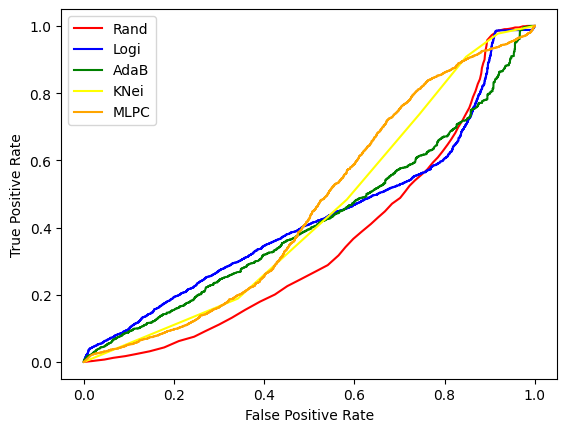

In [92]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import pickle



print("Started ")


data = pd.read_csv("../learn_redpitaya/2103_test_dataframe.csv", header=None)
X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable

data_for_roc_from_model = {}

def get_performance_metrices(model):
    print("Model : ", model.__str__())
    ytest_pred = model.predict_proba(X_test)
    # keep probabilities for the positive outcome only
    ytest_pred = ytest_pred[:, 1]
    auc_score = roc_auc_score(y_test, ytest_pred)
    #Confusion Matrix
    y_pred = model.predict(X_test)
    conf_matx = confusion_matrix(y_test, y_pred)
    model_f1_score = f1_score(y_test, y_pred)
    print("Confusion Matrix : ", conf_matx)
    print("F1 Score : ", model_f1_score)
    # summarize scores
    print('RF test ROC AUC=%.3f' % (auc_score))
    fpr, tpr, thresholds = roc_curve(y_test, ytest_pred)
    return {model.__str__().split("(")[0]: { "fpr": fpr, "tpr": tpr, "f1-score": model_f1_score, "roc auc": auc_score}}
    
    


def get_model(file_name="radom_forest_model.sav"):
    model = pickle.load(open(f"trained_model/{file_name}", "rb"))
    return model


list_of_models = ["radom_forest_model.sav", "logistic_model.sav", "ada_boost_model.sav", "knn_classifier_model.sav", "mlp_model.sav"]

list_of_scores = []

for model_name in list_of_models:
    trained_model = get_model(model_name)
    performance_score = get_performance_metrices(trained_model)
    list_of_scores.append(performance_score)
    
        
def plot_roc(fpr, tpr, color="None", label="None"):
    pyplot.plot(fpr, tpr, color, label=label)

colors = ["red", "blue", "green", "yellow", "orange"]

for indx, score in enumerate(list_of_scores):
    # print(indx, score)
    plot_roc(score[list(score.keys())[0]]["fpr"], score[list(score.keys())[0]]["tpr"], color=colors[indx], label=list(score.keys())[0][:4])
    
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

Started 
Model :  RandomForestClassifier()
Confusion Matrix :  [[25382  1576]
 [  171 29961]]
F1 Score :  0.9716713421654315
RF test ROC AUC=0.993
Model :  LogisticRegression(max_iter=40000)
Confusion Matrix :  [[21826  5132]
 [ 3161 26971]]
F1 Score :  0.8667470073109986
RF test ROC AUC=0.896
Model :  AdaBoostClassifier()
Confusion Matrix :  [[21447  5511]
 [ 2477 27655]]
F1 Score :  0.8738032797244779
RF test ROC AUC=0.905
Model :  KNeighborsClassifier()
Confusion Matrix :  [[24424  2534]
 [ 1440 28692]]
F1 Score :  0.9352325695100883
RF test ROC AUC=0.979
Model :  MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500)
Confusion Matrix :  [[25601  1357]
 [ 1103 29029]]
F1 Score :  0.959350936911332
RF test ROC AUC=0.986


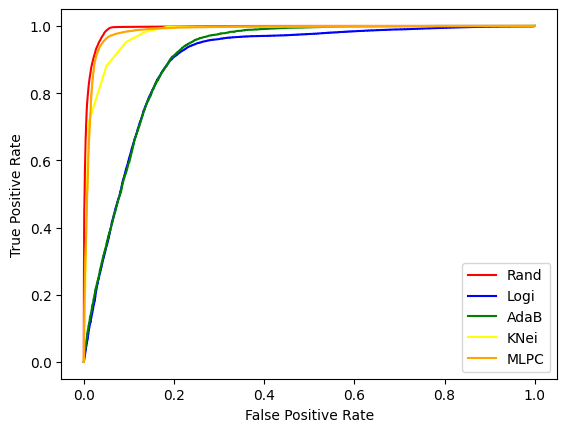

In [93]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import pickle



print("Started ")


data = pd.read_csv("../learn_redpitaya/60k_dataframe.csv", header=None)
X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable

data_for_roc_from_model = {}

def get_performance_metrices(model):
    print("Model : ", model.__str__())
    ytest_pred = model.predict_proba(X_test)
    # keep probabilities for the positive outcome only
    ytest_pred = ytest_pred[:, 1]
    auc_score = roc_auc_score(y_test, ytest_pred)
    #Confusion Matrix
    y_pred = model.predict(X_test)
    conf_matx = confusion_matrix(y_test, y_pred)
    model_f1_score = f1_score(y_test, y_pred)
    print("Confusion Matrix : ", conf_matx)
    print("F1 Score : ", model_f1_score)
    # summarize scores
    print('RF test ROC AUC=%.3f' % (auc_score))
    fpr, tpr, thresholds = roc_curve(y_test, ytest_pred)
    return {model.__str__().split("(")[0]: { "fpr": fpr, "tpr": tpr, "f1-score": model_f1_score, "roc auc": auc_score}}
    
    


def get_model(file_name="radom_forest_model.sav"):
    model = pickle.load(open(f"trained_model/{file_name}", "rb"))
    return model


list_of_models = ["radom_forest_model.sav", "logistic_model.sav", "ada_boost_model.sav", "knn_classifier_model.sav", "mlp_model.sav"]

list_of_scores = []

for model_name in list_of_models:
    trained_model = get_model(model_name)
    performance_score = get_performance_metrices(trained_model)
    list_of_scores.append(performance_score)
    
        
def plot_roc(fpr, tpr, color="None", label="None"):
    pyplot.plot(fpr, tpr, color, label=label)

colors = ["red", "blue", "green", "yellow", "orange"]

for indx, score in enumerate(list_of_scores):
    # print(indx, score)
    plot_roc(score[list(score.keys())[0]]["fpr"], score[list(score.keys())[0]]["tpr"], color=colors[indx], label=list(score.keys())[0][:4])
    
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

Started 
Model :  RandomForestClassifier()
Confusion Matrix :  [[11853  1576]
 [  171 14945]]
F1 Score :  0.9447798463824003
RF test ROC AUC=0.978
Model :  LogisticRegression(max_iter=40000)
Confusion Matrix :  [[10826  2603]
 [ 1615 13501]]
F1 Score :  0.8648942985265854
RF test ROC AUC=0.894
Model :  AdaBoostClassifier()
Confusion Matrix :  [[10645  2784]
 [ 1296 13820]]
F1 Score :  0.871374527112232
RF test ROC AUC=0.901
Model :  KNeighborsClassifier()
Confusion Matrix :  [[12031  1398]
 [  885 14231]]
F1 Score :  0.9257440234184421
RF test ROC AUC=0.969
Model :  MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500)
Confusion Matrix :  [[12395  1034]
 [  808 14308]]
F1 Score :  0.9395232779565305
RF test ROC AUC=0.972


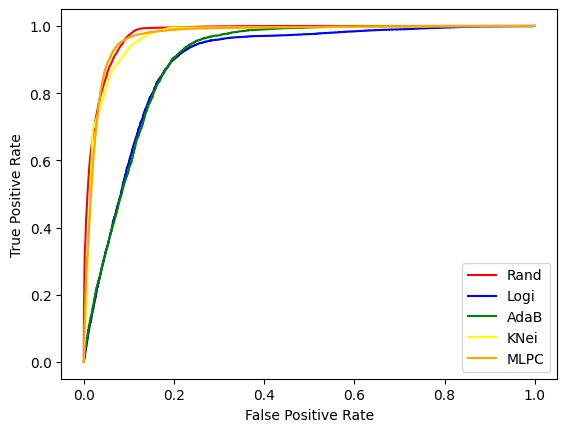

In [94]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import pickle



print("Started ")


data = pd.read_csv("../learn_redpitaya/60k_dataframe.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5 , random_state=42, shuffle=True)



data_for_roc_from_model = {}

def get_performance_metrices(model):
    print("Model : ", model.__str__())
    ytest_pred = model.predict_proba(X_test)
    # keep probabilities for the positive outcome only
    ytest_pred = ytest_pred[:, 1]
    auc_score = roc_auc_score(y_test, ytest_pred)
    #Confusion Matrix
    y_pred = model.predict(X_test)
    conf_matx = confusion_matrix(y_test, y_pred)
    model_f1_score = f1_score(y_test, y_pred)
    print("Confusion Matrix : ", conf_matx)
    print("F1 Score : ", model_f1_score)
    # summarize scores
    print('RF test ROC AUC=%.3f' % (auc_score))
    fpr, tpr, thresholds = roc_curve(y_test, ytest_pred)
    return {model.__str__().split("(")[0]: { "fpr": fpr, "tpr": tpr, "f1-score": model_f1_score, "roc auc": auc_score}}
    
    


def get_model(file_name="radom_forest_model.sav"):
    model = pickle.load(open(f"trained_model/{file_name}", "rb"))
    return model


list_of_models = ["radom_forest_model.sav", "logistic_model.sav", "ada_boost_model.sav", "knn_classifier_model.sav", "mlp_model.sav"]

list_of_scores = []

for model_name in list_of_models:
    trained_model = get_model(model_name)
    performance_score = get_performance_metrices(trained_model)
    list_of_scores.append(performance_score)
    
        
def plot_roc(fpr, tpr, color="None", label="None"):
    pyplot.plot(fpr, tpr, color, label=label)

colors = ["red", "blue", "green", "yellow", "orange"]

for indx, score in enumerate(list_of_scores):
    # print(indx, score)
    plot_roc(score[list(score.keys())[0]]["fpr"], score[list(score.keys())[0]]["tpr"], color=colors[indx], label=list(score.keys())[0][:4])
    
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

Started 
Model :  RandomForestClassifier()
Confusion Matrix :  [[3446 4937]
 [  91 7924]]
F1 Score :  0.7591492623107875
RF test ROC AUC=0.856
Model :  LogisticRegression(max_iter=40000)
Confusion Matrix :  [[6269 2114]
 [ 863 7152]]
F1 Score :  0.8277298767432439
RF test ROC AUC=0.834
Model :  AdaBoostClassifier()
Confusion Matrix :  [[5323 3060]
 [ 549 7466]]
F1 Score :  0.8053503047300578
RF test ROC AUC=0.825
Model :  KNeighborsClassifier()
Confusion Matrix :  [[5974 2409]
 [ 788 7227]]
F1 Score :  0.8188771174437709
RF test ROC AUC=0.835
Model :  MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500)
Confusion Matrix :  [[3699 4684]
 [ 656 7359]]
F1 Score :  0.7337720610230333
RF test ROC AUC=0.810


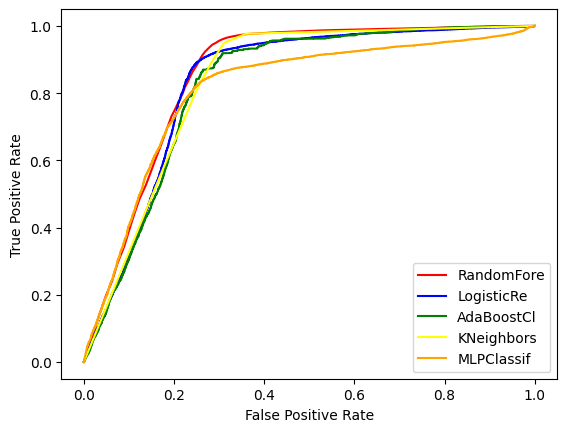

In [96]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import pickle



print("Started ")


data = pd.read_csv("../learn_redpitaya/test2_2103_16k_dataframe.csv", header=None)
X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable

data_for_roc_from_model = {}

def get_performance_metrices(model):
    print("Model : ", model.__str__())
    ytest_pred = model.predict_proba(X_test)
    # keep probabilities for the positive outcome only
    ytest_pred = ytest_pred[:, 1]
    auc_score = roc_auc_score(y_test, ytest_pred)
    #Confusion Matrix
    y_pred = model.predict(X_test)
    conf_matx = confusion_matrix(y_test, y_pred)
    model_f1_score = f1_score(y_test, y_pred)
    print("Confusion Matrix : ", conf_matx)
    print("F1 Score : ", model_f1_score)
    # summarize scores
    print('RF test ROC AUC=%.3f' % (auc_score))
    fpr, tpr, thresholds = roc_curve(y_test, ytest_pred)
    return {model.__str__().split("(")[0]: { "fpr": fpr, "tpr": tpr, "f1-score": model_f1_score, "roc auc": auc_score}}
    
    


def get_model(file_name="radom_forest_model.sav"):
    model = pickle.load(open(f"trained_model40k/{file_name}", "rb"))
    return model


list_of_models = ["radom_forest_model.sav", "logistic_model.sav", "ada_boost_model.sav", "knn_classifier_model.sav", "mlp_model.sav"]

list_of_scores = []

for model_name in list_of_models:
    trained_model = get_model(model_name)
    performance_score = get_performance_metrices(trained_model)
    list_of_scores.append(performance_score)
    
        
def plot_roc(fpr, tpr, color="None", label="None"):
    pyplot.plot(fpr, tpr, color, label=label)

colors = ["red", "blue", "green", "yellow", "orange"]

for indx, score in enumerate(list_of_scores):
    # print(indx, score)
    plot_roc(score[list(score.keys())[0]]["fpr"], score[list(score.keys())[0]]["tpr"], color=colors[indx], label=list(score.keys())[0][:10])
    
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

# Test with prediction for all models

Started 
Model :  RandomForestClassifier()
Confusion Matrix :  [[3662 4721]
 [  87 7928]]
F1 Score :  0.767324816105304
RF test ROC AUC=0.713
Model :  LogisticRegression(max_iter=40000)
Confusion Matrix :  [[6269 2114]
 [ 863 7152]]
F1 Score :  0.8277298767432439
RF test ROC AUC=0.820
Model :  AdaBoostClassifier()
Confusion Matrix :  [[5323 3060]
 [ 549 7466]]
F1 Score :  0.8053503047300578
RF test ROC AUC=0.783
Model :  KNeighborsClassifier()
Confusion Matrix :  [[5974 2409]
 [ 788 7227]]
F1 Score :  0.8188771174437709
RF test ROC AUC=0.807
Model :  MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500)
Confusion Matrix :  [[ 638 7745]
 [ 829 7186]]
F1 Score :  0.62634010285017
RF test ROC AUC=0.486
Model :  Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(gamma='auto'))])
Confusion Matrix :  [[5342 3041]
 [  94 7921]]
F1 Score :  0.8348000210781472
RF test ROC AUC=0.813
Model :  Pipeline(steps=[('standardscaler', StandardScaler()),
            

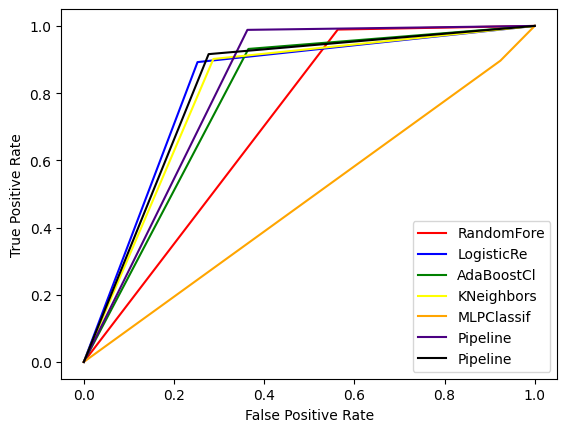

In [100]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import pickle



print("Started ")


data = pd.read_csv("../learn_redpitaya/test2_2103_16k_dataframe.csv", header=None)
X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable

data_for_roc_from_model = {}

def get_performance_metrices(model):
    print("Model : ", model.__str__())
    ytest_pred = model.predict(X_test)
    auc_score = roc_auc_score(y_test, ytest_pred)
    #Confusion Matrix
    y_pred = model.predict(X_test)
    conf_matx = confusion_matrix(y_test, y_pred)
    model_f1_score = f1_score(y_test, y_pred)
    print("Confusion Matrix : ", conf_matx)
    print("F1 Score : ", model_f1_score)
    # summarize scores
    print('RF test ROC AUC=%.3f' % (auc_score))
    fpr, tpr, thresholds = roc_curve(y_test, ytest_pred)
    return {model.__str__().split("(")[0]: { "fpr": fpr, "tpr": tpr, "f1-score": model_f1_score, "roc auc": auc_score}}
    
    


def get_model(file_name="radom_forest_model.sav"):
    model = pickle.load(open(f"trained_model40k/{file_name}", "rb"))
    return model


list_of_models = ["radom_forest_model.sav", "logistic_model.sav", "ada_boost_model.sav", 
                  "knn_classifier_model.sav", "mlp_model.sav", "svm_gamma_auto.sav", "svm_kernel_linear.sav"]

list_of_scores = []

for model_name in list_of_models:
    trained_model = get_model(model_name)
    performance_score = get_performance_metrices(trained_model)
    list_of_scores.append(performance_score)
    
        
def plot_roc(fpr, tpr, color="None", label="None"):
    pyplot.plot(fpr, tpr, color, label=label)

colors = ["red", "blue", "green", "yellow", "orange", "indigo", "black"]

for indx, score in enumerate(list_of_scores):
    # print(indx, score)
    plot_roc(score[list(score.keys())[0]]["fpr"], score[list(score.keys())[0]]["tpr"], color=colors[indx], label=list(score.keys())[0][:10])
    
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

# Hyper parameter tunning 

In [104]:
from sklearn.model_selection import RandomizedSearchCV
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]
# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
print(random_grid)

{'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000], 'max_features': ['auto', 'sqrt'], 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'bootstrap': [True, False]}


#### On each iteration, the algorithm will choose a difference combination of the features. Altogether, there are 2 * 12 * 2 * 3 * 3 * 10 = 4320 settings! However, the benefit of a random search is that we are not trying every combination, but selecting at random to sample a wide range of values.

In [ ]:

from sklearn.ensemble import RandomForestRegressor

# loading data and splitting
data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)



# Use the random grid to search for best hyperparameters
# First create the base model to tune
rf = RandomForestRegressor()
# Random search of parameters, using 3 fold cross validation, 
# search across 100 different combinations, and use all available cores
rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 20, cv = 3, verbose=2, random_state=42, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train)

print(rf_random.best_params_)



Fitting 3 folds for each of 20 candidates, totalling 60 fits


/Users/bisalgt/Projects/playground/env/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
/Users/bisalgt/Projects/playground/env/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
/Users/bisalgt/Projects/playground/env/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0`